In [2]:
import numpy as np
import miepython
import matplotlib.pyplot as plt

In [3]:
data = np.genfromtxt('https://refractiveindex.info/tmp/database/data-nk/main/Ag/Johnson.txt', delimiter='\t')
N = len(data)//2
waveLength = data[1:N,0]
realRefractiveInd = data[1:N,1]
imRefractiveInd = - data[N+1:,1] #refractive index va negativo
refractiveIndex = realRefractiveInd + 1.0j*imRefractiveInd

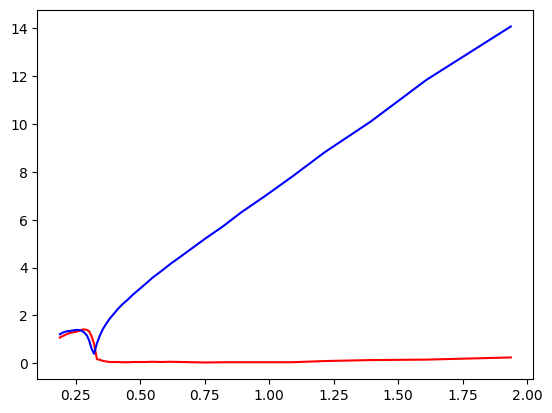

In [4]:
plt.plot(waveLength, realRefractiveInd, "red")
plt.plot(waveLength, - imRefractiveInd, "blue")
plt.show()

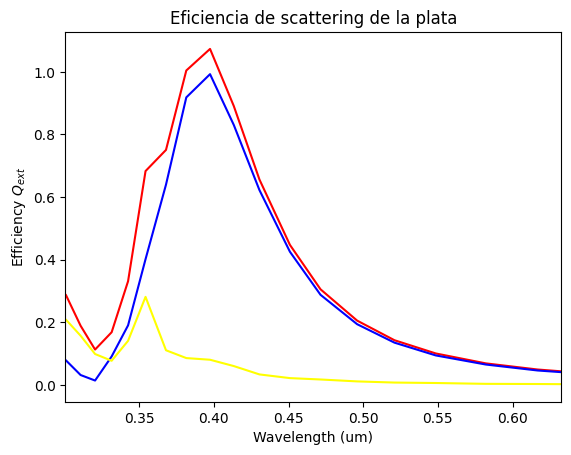

In [23]:
diameter = 0.1 #um ... 100nm diameter
qext, qsca, qback, g = miepython.ez_mie(refractiveIndex, diameter, waveLength)

plt.plot(waveLength,qext*(4*np.pi*diameter**2),color='red')
plt.plot(waveLength,qsca*(4*np.pi*diameter**2),color='blue')
plt.plot(waveLength,(qext-qsca)*(4*np.pi*diameter**2),color='yellow')


# para el rango de x que sea la mitad
ax = plt.gca()
x_limits = ax.get_xlim()
ax.set_xlim(x_limits[0]+0.2, x_limits[1] / 3.2)

plt.xlabel("Wavelength (um)")
plt.ylabel("Efficiency $Q_{ext}$")
plt.title("Eficiencia de scattering de la plata")
plt.show()

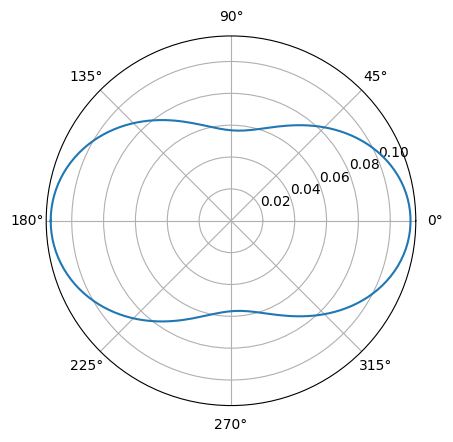

In [19]:
theta = np.linspace(180,-180,180)*np.pi/180.0
mu = np.cos(theta)
sizeParameter = np.pi*diameter/waveLength #sP = 2pi d/2 /lambda
scatteredIntensity = miepython.i_unpolarized(refractiveIndex[30],sizeParameter[30], mu)
plt.polar(theta, scatteredIntensity)

49
0 0.1621884129331274


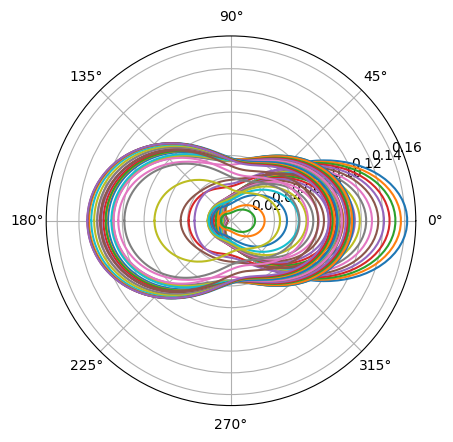

In [22]:
maxVal = 0
print(len(waveLength))
for i in range(len(waveLength)):
    scatteredIntensity = miepython.i_unpolarized(refractiveIndex[i],sizeParameter[i], mu)
    plt.polar(theta, scatteredIntensity)
    #plt.plot(theta, scatteredIntensity)
    if max(scatteredIntensity)>maxVal:
        maxVal = max(max(scatteredIntensity), maxVal)
        index = i
print(index, maxVal)

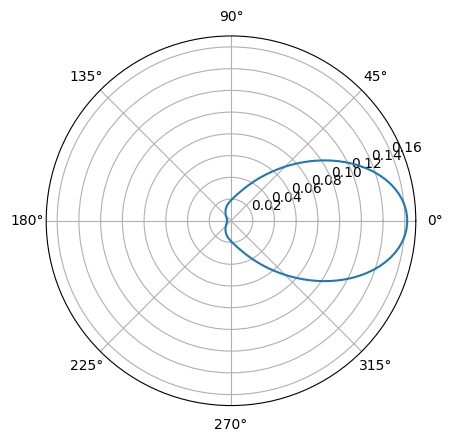

In [23]:
maxScatteredIntensity = miepython.i_unpolarized(refractiveIndex[index],sizeParameter[index], mu)
plt.polar(theta, maxScatteredIntensity)